# Plotting animal words

we will practice forming and testing hypotheses with explanatory mechanisms. The focus will be on a dataset derived from a subset of the Google Books Initiative. The subset tracks the publication frequencies for hundreds of animal words in printed materials over the past 300 years.

### Load the data

we'll use the data file `animal-word-trends.csv`. This tracks the historical usage frequency of animal words in printed materials.

In this dataset, word frequency is normalized to the total words published each year. Specifically, the frequency column measures the number of occurrences of a word in a year per million words published that year.


In [21]:
import matplotlib.pyplot as plt
import pandas as pd


In [22]:
word_trends = pd.read_csv('animal-word-trends-intro.csv')
word_trends 

,year,word,frequency
0,1700,cat,11.601
1,1700,dinosaur,0.000
2,1700,dog,29.388
3,1700,goat,16.707
4,1700,horse,107.127
...,...,...,...
3140,2019,lobster,2.860
3141,2019,penguin,9.146
3142,2019,shrimp,3.948
3143,2019,tuna,2.493


The years in this dataset span from 1700 to 2019.

In 2019, the word "zebra" occurred 1.106 times for every million total words published.

### Plotting trends



In [23]:
trend = word_trends.query('word == "horse"')
trend 

,year,word,frequency
4,1700,horse,107.127
13,1701,horse,119.436
22,1702,horse,135.049
31,1703,horse,150.645
40,1704,horse,163.304
...,...,...,...
3099,2015,horse,91.868
3109,2016,horse,93.777
3119,2017,horse,95.808
3129,2018,horse,97.602


We can see that "horse" is used almost 100 times more frequently than the word "zebra".


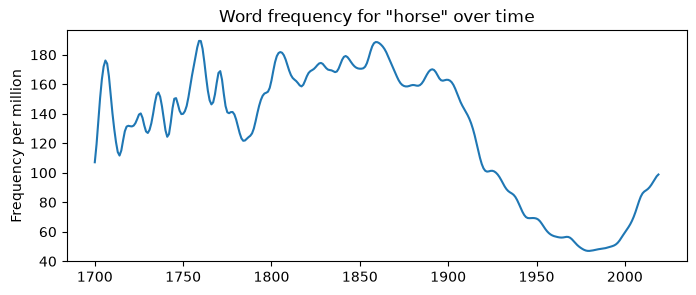

In [24]:
plt.figure(figsize=(8, 3))
plt.plot(trend['year'], trend['frequency'])
plt.ylabel('Frequency per million')
plt.title('Word frequency for "horse" over time')
plt.show()


### Making a reusable function


In [31]:
def plot_word_trend( animal ):
	plt.gcf().set_size_inches(8, 3)
	trend = word_trends.query('word == @animal')
	plt.plot(trend['year'], trend['frequency'], label=animal)
	plt.ylabel('Frequency per million')

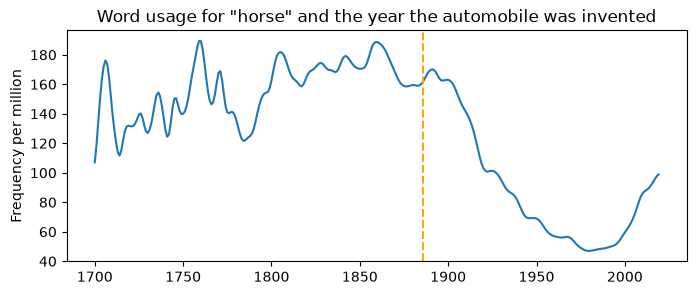

In [26]:
plot_word_trend('horse')
plt.axvline(1886, color='orange', ls='--')
plt.title('Word usage for "horse" and the year the automobile was invented')
plt.show()

After the invention of the horseless carriage, the usage of the word "horse" shows a slight increase followed by a large decrease.

Is this a coincidence, or is there a potential data story here 🤔?

### Plotting multiple trends
We can invoke our function multiple times to visualize multiple trends on the same graph.

For example, which word do you think is used more often in print: "penguin" or "dinosaur"?

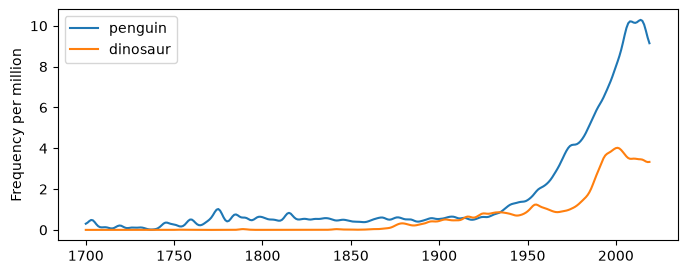

In [27]:
plot_word_trend('penguin')
plot_word_trend('dinosaur')
plt.legend()
plt.show()

And the winner is penguin, which is published about 3 times as frequently. Did you expect that?

### Exploring and forming hypotheses
The US transcontinental railway was completed in 1869. Did this have an impact on the usage of animal words? Using the `plot_word_trend()` function, explore each of the following four animal words:


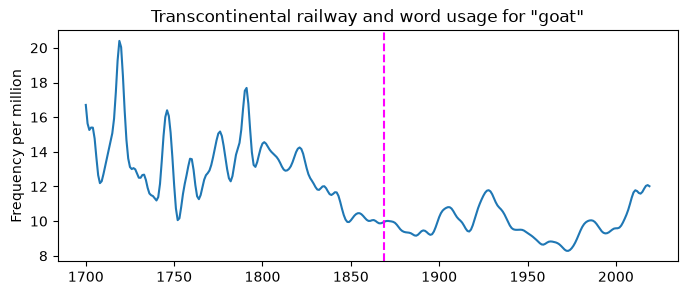

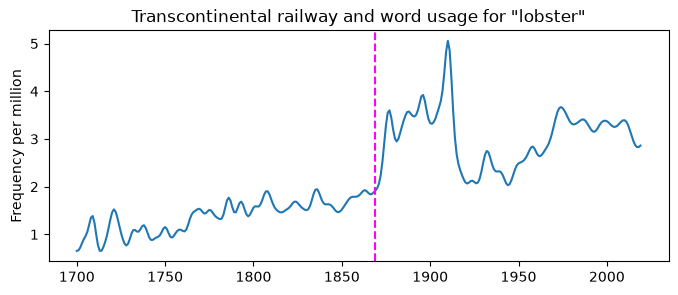

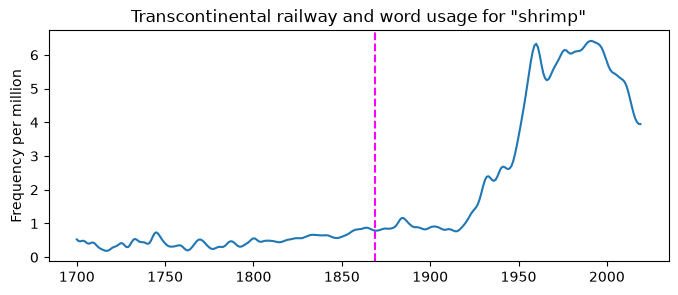

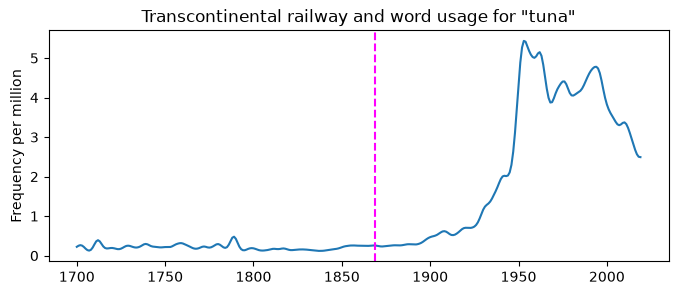

In [33]:
def plot_word_trend_railway(animal):
	plt.figure(figsize=(3,2))
	plot_word_trend(animal)
	plt.axvline(1869, color='magenta', ls='--')
	plt.title(f'Transcontinental railway and word usage for "{animal}"')

animals = ['goat', 'lobster', 'shrimp', 'tuna']
for animal in animals:
	plot_word_trend_railway(animal)


### Explanatory mechanisms

We observed a sharp increase in usage frequency for the word "lobster" after the completion of the transcontinental railway. One hypothesis is that this is causal and the railway helped increase popularity of lobster.


While correlation does not prove causation, evidence for causation is stronger when there is a logical explanationory mechanism.

## Project extensions


#### Extension 1: "cats" or "dogs" ?

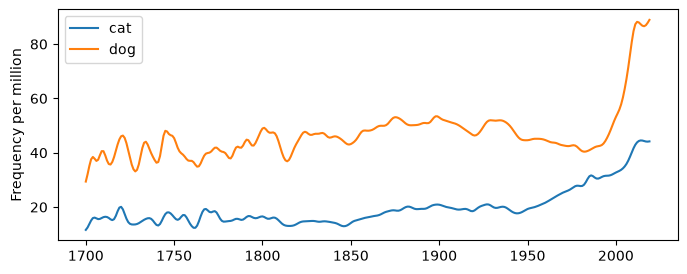

In [35]:
plot_word_trend('cat')
plot_word_trend('dog')
plt.legend()

 * Both animals have seen a massive explosion in mentions starting around 1970, reflecting the modern shift in treating pets as primary family members. However, "dog" has maintained a lead of roughly 2:1 over "cat" for the last 300 years.

### Conclusion

This project shows that word frequency in literature reflects changes in technology, society, and human values. Over 319 years, animals once valued for utility, such as horses, declined as technology evolved, while animals linked to companionship, science, and education became more prominent.

The analysis also highlights how infrastructure, such as railways, can influence cultural popularity by making products more accessible.

Overall, the project demonstrates that data storytelling goes beyond visualizing trends: it connects statistical patterns with historical events to reveal how literature reflects our changing world.
